In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data Preprocessing

In [27]:
dataset = pd.read_csv('4.2 Churn_Modelling.csv')
dataset

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [28]:
x = dataset.iloc[:, 3:13].values
y = dataset.iloc[:, 13].values
print(x)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [29]:
print(y)

[1 0 1 ... 1 1 0]


In [30]:

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
labelencoder_x_2 = LabelEncoder()
x[:, 2] = labelencoder_x_2.fit_transform(x[:, 2])
print(x)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


In [31]:
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer([('ohe', OneHotEncoder(), [1])], remainder='passthrough')
x = np.array(ct.fit_transform(x), dtype = str) #.toarray()
x = x[:, 1:]
print(x)

[['0.0' '0.0' '619' ... '1' '1' '101348.88']
 ['0.0' '1.0' '608' ... '0' '1' '112542.58']
 ['0.0' '0.0' '502' ... '1' '0' '113931.57']
 ...
 ['0.0' '0.0' '709' ... '0' '1' '42085.58']
 ['1.0' '0.0' '772' ... '1' '0' '92888.52']
 ['0.0' '0.0' '792' ... '1' '0' '38190.78']]


In [32]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [33]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
x_train

array([[-0.5698444 ,  1.74309049,  0.16958176, ...,  0.64259497,
        -1.03227043,  1.10643166],
       [ 1.75486502, -0.57369368, -2.30455945, ...,  0.64259497,
         0.9687384 , -0.74866447],
       [-0.5698444 , -0.57369368, -1.19119591, ...,  0.64259497,
        -1.03227043,  1.48533467],
       ...,
       [-0.5698444 , -0.57369368,  0.9015152 , ...,  0.64259497,
        -1.03227043,  1.41231994],
       [-0.5698444 ,  1.74309049, -0.62420521, ...,  0.64259497,
         0.9687384 ,  0.84432121],
       [ 1.75486502, -0.57369368, -0.28401079, ...,  0.64259497,
        -1.03227043,  0.32472465]])

# Creation du Model

In [35]:

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Input

import tensorflow as tf
import random

# Fixer les seeds
## np.random.seed(42)
## tf.random.set_seed(42)
## random.seed(42)

# Nettoyer les sessions précédentes (important dans Jupyter)
tf.keras.backend.clear_session()

classifier = Sequential()


# Il y a desequilibre entre le valeur de sortie donc on calcul le poids automatiquement

In [36]:
from sklearn.utils import class_weight

# Calcul automatique des poids par classe parce que les class sont desequilibré
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

In [37]:
# Création du modèle
classifier.add(Input(shape=(11,)))  # input layer propre
classifier.add(Dense(units=32, kernel_initializer='uniform', activation='relu'))
classifier.add(Dense(units=16, kernel_initializer='uniform', activation='relu'))
classifier.add(Dense(units=8, kernel_initializer='uniform', activation='relu'))
classifier.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

### on a creer un modele avec 3 couche cahcé maintenant il faut le compilé

In [38]:
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [39]:
# Sauvegarde du meilleur modèle
checkpoint = ModelCheckpoint('Save/temp_modele.jupiter.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

In [40]:
# Entraînement
history = classifier.fit(x_train, y_train, batch_size=10, epochs=100, validation_split=0.2, callbacks=[checkpoint], class_weight = class_weight_dict)

Epoch 1/100
639/640 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2589 - loss: 0.7024
Epoch 1: val_accuracy improved from -inf to 0.79688, saving model to Save/temp_modele.jupiter.keras
640/640 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2590 - loss: 0.7024 - val_accuracy: 0.7969 - val_loss: 0.6918
Epoch 2/100
637/640 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6732 - loss: 0.6916
Epoch 2: val_accuracy did not improve from 0.79688
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6734 - loss: 0.6916 - val_accuracy: 0.2031 - val_loss: 0.6935
Epoch 3/100
633/640 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2344 - loss: 0.6961
Epoch 3: val_accuracy did not improve from 0.79688
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2343 - loss: 0.6961 - val_accuracy: 0.7969 - val_loss: 0.6931
Epoch 4/100
624/640 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3739 - loss: 0.6972
Epoch 4: val_accuracy did not improve from 0.79688
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accur

# Chargement du nouveau modèle seulement si elle est meilleur que l'ancienne

In [41]:

from sklearn.metrics import roc_auc_score
import os

# Charger le modèle temporaire (le nouveau)
nouveau_model_path = "Save/temp_modele.jupiter.keras"
ancien_model_path = "Save/meilleur_modele_jupy.keras"

if os.path.exists(nouveau_model_path):
    nouveau_modele = load_model(nouveau_model_path)
    y_proba_nouveau = nouveau_modele.predict(x_test)
    auc_nouveau = roc_auc_score(y_test, y_proba_nouveau)

    if os.path.exists(ancien_model_path):
        ancien_modele = load_model(ancien_model_path)
        y_proba_ancien = ancien_modele.predict(x_test)
        auc_ancien = roc_auc_score(y_test, y_proba_ancien)

        print(f"\n🎯 Ancien AUC : {auc_ancien:.3f}")
        print(f"🚀 Nouveau AUC : {auc_nouveau:.3f}")

        if auc_nouveau > auc_ancien:
            print("✅ Nouveau modèle meilleur → Remplacement effectué.")
            nouveau_modele.save(ancien_model_path)
            meilleur_modele = nouveau_modele
        else:
            print("❌ Ancien modèle conservé (meilleur AUC).")
            meilleur_modele = ancien_modele
    else:
        print("📁 Aucun modèle précédent. Le modèle actuel devient le meilleur.")
        nouveau_modele.save(ancien_model_path)
        meilleur_modele = nouveau_modele
else:
    raise FileNotFoundError("Aucun modèle temporaire trouvé après l'entraînement.")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

🎯 Ancien AUC : 0.852
🚀 Nouveau AUC : 0.500
❌ Ancien modèle conservé (meilleur AUC).


# Prédiction avec le meilleur modèle
# Probabilités (score entre 0 et 1)

In [42]:
y_proba = meilleur_modele.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


# On test les seuil pour trouver la meilleur vu que les class partante et restant sont desequilibré

In [43]:
from sklearn.metrics import f1_score

# Tester plusieurs seuils entre 0.1 et 0.9
# Recherche du meilleur seuil basé sur F1-score
seuils = np.arange(0.1, 0.9, 0.01)
f1_scores = []

# Une boucle pour verifier tous les seuil vu que le resultat sont desequilibré trop de false par rapport au True donc

In [44]:
for seuil in seuils:
    y_pred_test = (y_proba > seuil)
    score = f1_score(y_test, y_pred_test)
    f1_scores.append(score)

meilleur_seuil = seuils[np.argmax(f1_scores)]
meilleur_f1 = max(f1_scores)

In [45]:
print(f"\n💡 Meilleur seuil selon F1-score : {meilleur_seuil:.2f}")
print(f"🔍 F1-score associé : {meilleur_f1:.3f}")


💡 Meilleur seuil selon F1-score : 0.63
🔍 F1-score associé : 0.617


In [46]:
# Prédictions finales avec le meilleur seuil
y_pred = (y_proba > meilleur_seuil)

# Matrice de confusion avec meilleur seuil

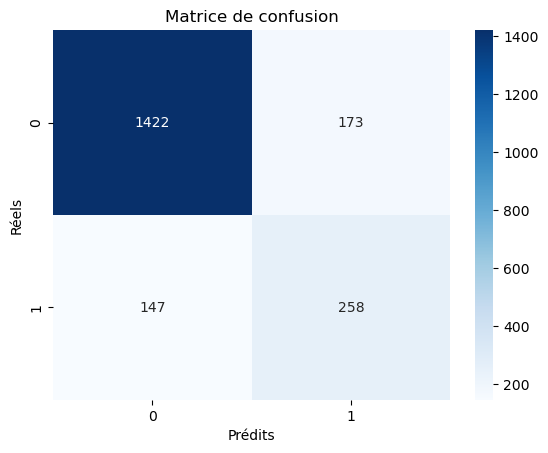

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédits')
plt.ylabel('Réels')
plt.title('Matrice de confusion')
plt.show()

# Calculer les métriques de performance

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)
error_rate = 1 - accuracy


In [49]:
print("=== MÉTRIQUES DE PERFORMANCE ===")
print(f"Accuracy (Précision globale): {accuracy:.3f}")
print(f"Précision (pour classe positive): {precision:.3f}")
print(f"Sensibilité/Recall (pour classe positive): {sensitivity:.3f}")
print(f"Spécificité (pour classe négative): {specificity:.3f}")
print(f"Taux d'erreur: {error_rate:.3f}")

=== MÉTRIQUES DE PERFORMANCE ===
Accuracy (Précision globale): 0.840
Précision (pour classe positive): 0.599
Sensibilité/Recall (pour classe positive): 0.637
Spécificité (pour classe négative): 0.892
Taux d'erreur: 0.160


# Tracer la courbe F1 en fonction du seuil

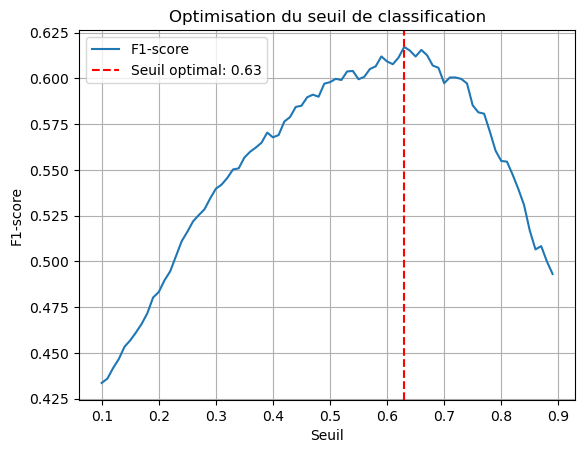

In [50]:
plt.figure()
plt.plot(seuils, f1_scores, label='F1-score')
plt.xlabel("Seuil")
plt.ylabel("F1-score")
plt.title("Optimisation du seuil de classification")
plt.axvline(x=meilleur_seuil, color='r', linestyle='--', label=f'Seuil optimal: {meilleur_seuil:.2f}')
plt.legend()
plt.grid(True)
plt.show()

# Courbe ROC & AUC

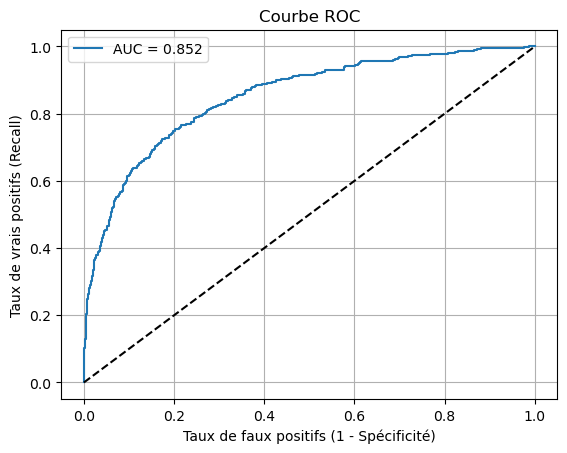

In [51]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Taux de faux positifs (1 - Spécificité)")
plt.ylabel("Taux de vrais positifs (Recall)")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.show()


# C'est la fin sauf si on voudra ajouté une chose